## Estadística Descriptiva

Vamos a cargar nuestro dataset.

In [1]:
import pandas as pd 

habits = pd.read_csv("/home/yamorza/Documentos/espacio_trabajo_intro_analisis_dat2/proyecto_modulo_6/src/habits.csv")
habits.head(5)

,age,gender,study_hours_per_day,social_media_hours,netflix_hours,part_time_job,attendance_percentage,sleep_hours,diet_quality,exercise_frequency,parental_education_level,internet_quality,mental_health_rating,extracurricular_participation,exam_score
0,23,Female,0.0,1.2,1.1,No,85.0,8.0,Fair,6,Master,Average,8,Yes,56.2
1,20,Female,6.9,2.8,2.3,No,97.3,4.6,Good,6,High School,Average,8,No,100.0
2,21,Male,1.4,3.1,1.3,No,94.8,8.0,Poor,1,High School,Poor,1,No,34.3
3,23,Female,1.0,3.9,1.0,No,71.0,9.2,Poor,4,Master,Good,1,Yes,26.8
4,19,Female,5.0,4.4,0.5,No,90.9,4.9,Fair,3,Master,Good,1,No,66.4


Tenemos 4 variables categorícas: 
- `gender`
- `diet_quality`
- `parental_education_level`
- `internet_quality`

Dos booleanas:
- `extracurricular_participation`
- `part_time_job`

El resto de las variables son numéricas.
La distribución por geńero del dataset es la siguiente:

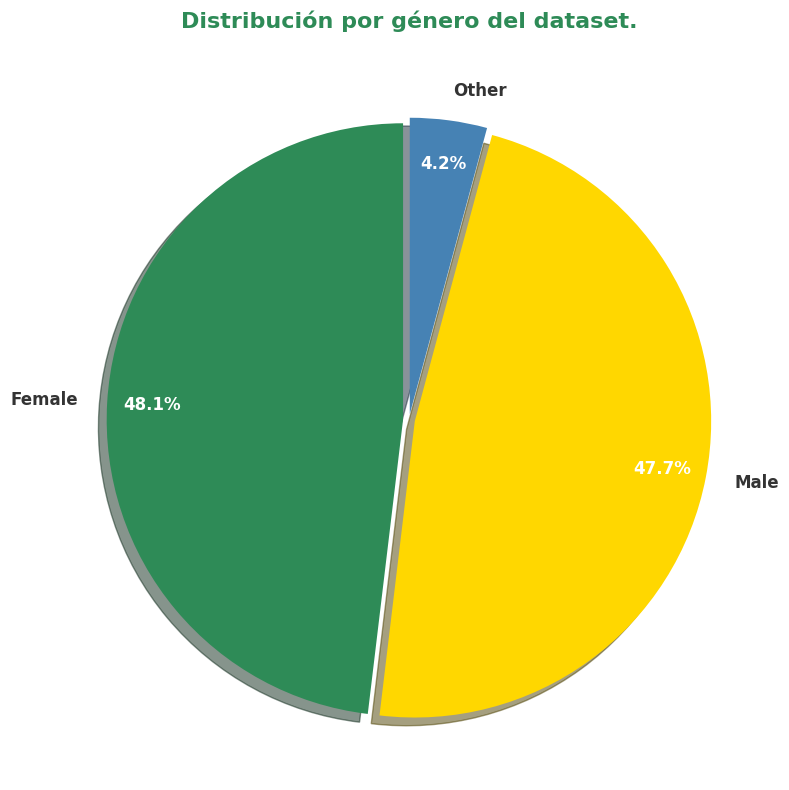

In [2]:
import pandas as pd
import matplotlib.pyplot as plt


gender_counts = habits['gender'].value_counts()

colors = ['#2E8B57', '#FFD700', '#4682B4', '#FF8C00', '#8B4513', '#DC143C']

plt.figure(figsize=(8, 8))
wedges, texts, autotexts = plt.pie(
    gender_counts.values, 
    labels=gender_counts.index, 
    autopct='%1.1f%%', 
    startangle=90,
    colors=colors[:len(gender_counts)],
    shadow=True,
    explode=[0.02] * len(gender_counts),
    textprops={'fontsize': 12, 'fontweight': 'bold', 'color': '#333333'},
    pctdistance=0.85
)

for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontsize(12)
    autotext.set_fontweight('bold')

plt.title('Distribución por género del dataset.', 
          fontsize=16, 
          fontweight='bold',
          color='#2E8B57',  # Chalkboard green for title
          pad=20)

plt.axis('equal')
plt.tight_layout()



In [3]:
import pandas as pd
from ydata_profiling import ProfileReport
import json 
profile = ProfileReport(habits, title="Habits EDA")





/tmp/ipykernel_44923/1623793960.py:2: DeprecationWarning: 
    `import ydata_profiling` is deprecated and will not receive more updates. 
    Please install fg-data-profiling via `pip install fg-data-profiling` and use `import data_profiling` instead.
    
  from ydata_profiling import ProfileReport


In [4]:
correlation_matrix = profile.to_json()
correlation_matrix = json.loads(correlation_matrix)
correlation_matrix = correlation_matrix["correlations"]
correlation_matrix

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]

100%|██████████| 15/15 [00:00<00:00, 182891.16it/s]


Render JSON:   0%|          | 0/1 [00:00<?, ?it/s]

{'auto': [{'age': 1.0,
   'attendance_percentage': -0.02345069683546379,
   'diet_quality': 0.0,
   'exam_score': -0.010017075621785774,
   'exercise_frequency': -0.003872370813430791,
   'extracurricular_participation': 0.07913007959106655,
   'gender': 0.0,
   'internet_quality': 0.02447594963098058,
   'mental_health_rating': -0.045543968079583816,
   'netflix_hours': 0.001955182420245476,
   'parental_education_level': 0.0,
   'part_time_job': 0.0,
   'sleep_hours': 0.03853670471546743,
   'social_media_hours': -0.011915540224399385,
   'study_hours_per_day': 0.0017355604733132871},
  {'age': -0.02345069683546379,
   'attendance_percentage': 1.0,
   'diet_quality': 0.0,
   'exam_score': 0.09389846415147456,
   'exercise_frequency': -0.009074323650472586,
   'extracurricular_participation': 0.0,
   'gender': 0.0200401099005672,
   'internet_quality': 0.05197988448545506,
   'mental_health_rating': -0.007891559455650067,
   'netflix_hours': -0.0021760102039617784,
   'parental_educat

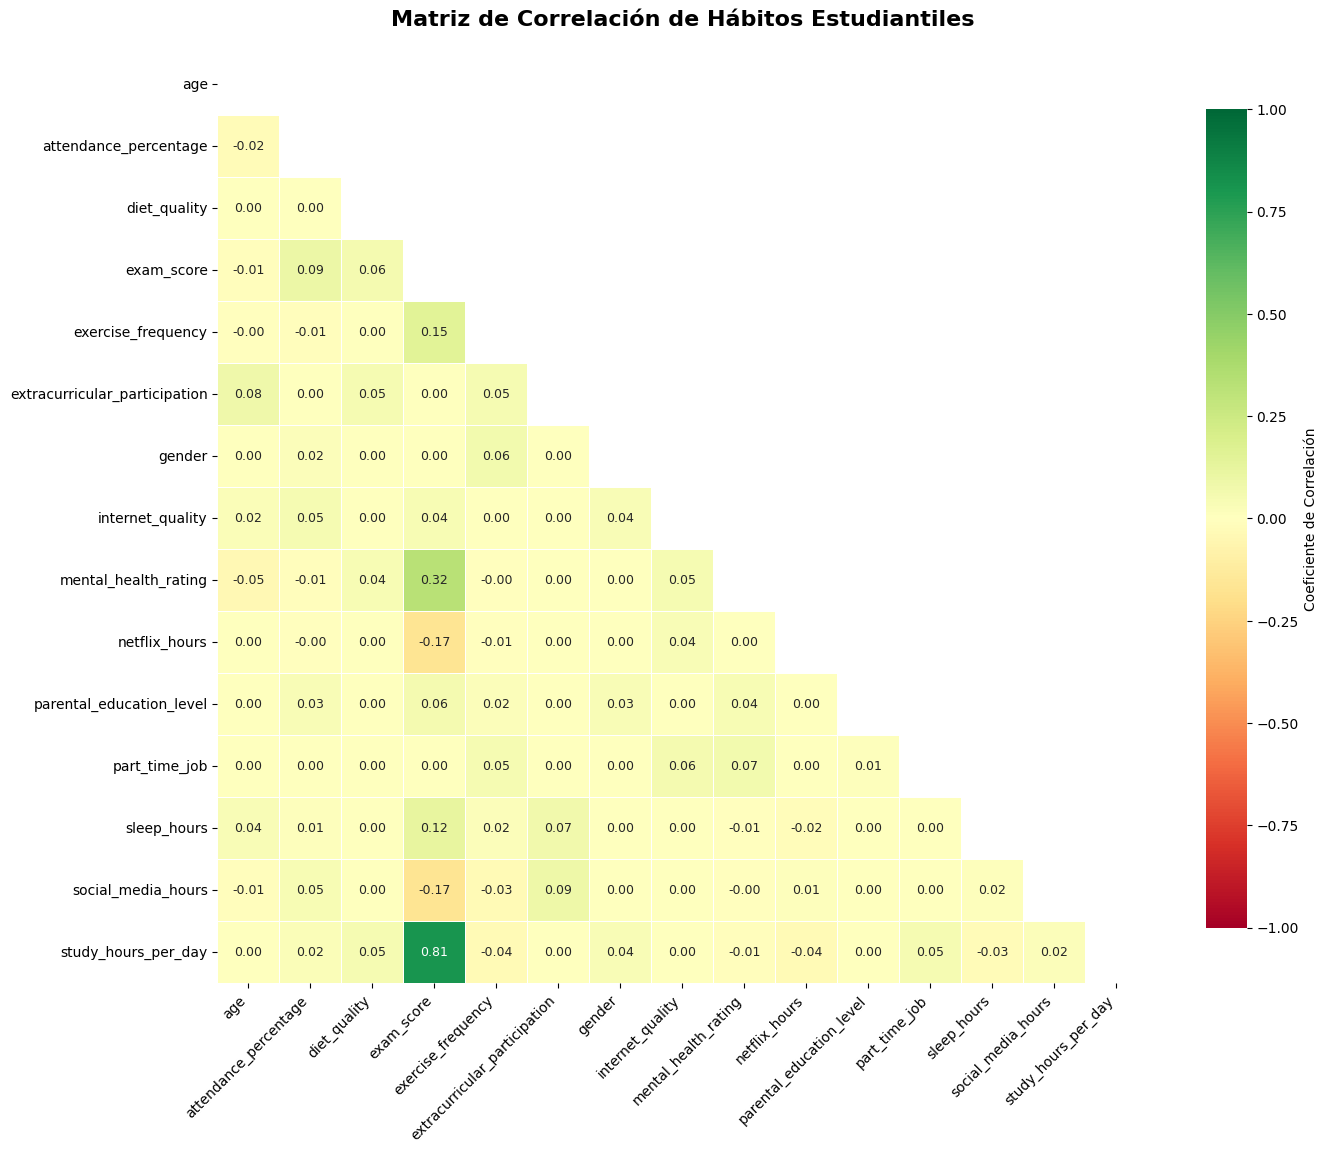


Correlaciones con exam_score:
exam_score                       1.000000
study_hours_per_day              0.812078
mental_health_rating             0.323364
exercise_frequency               0.150205
sleep_hours                      0.123396
attendance_percentage            0.093898
parental_education_level         0.060922
diet_quality                     0.055099
internet_quality                 0.044775
extracurricular_participation    0.000000
gender                           0.000000
part_time_job                    0.000000
age                             -0.010017
netflix_hours                   -0.165195
social_media_hours              -0.166259
Name: exam_score, dtype: float64


In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

lista_correlaciones = correlation_matrix['auto']

nombres_variables = list(lista_correlaciones[0].keys())

matriz = []
for fila in lista_correlaciones:
    matriz.append([fila[var] for var in nombres_variables])

correlaciones_df = pd.DataFrame(matriz, index=nombres_variables, columns=nombres_variables)

plt.figure(figsize=(14, 12))

mask = np.triu(np.ones_like(correlaciones_df, dtype=bool))

sns.heatmap(
    correlaciones_df,
    mask=mask,
    annot=True,
    fmt='.2f',
    cmap='RdYlGn',
    center=0,
    square=True,
    linewidths=0.5,
    cbar_kws={"shrink": 0.8, "label": "Coeficiente de Correlación"},
    annot_kws={'size': 9},
    vmin=-1,
    vmax=1
)

plt.title('Matriz de Correlación de Hábitos Estudiantiles', 
          fontsize=16, 
          fontweight='bold',
          pad=20)

plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(rotation=0, fontsize=10)

plt.tight_layout()
plt.show()

print("\nCorrelaciones con exam_score:")
print(correlaciones_df['exam_score'].sort_values(ascending=False))



Notamos lo siguiente:
- La correlación más alta es la de `exam_score` con `study_hours_per_day` con `0.81`. 
- La segunda correlación más alta es la de `exam_score` con `mental_health_rating` con `0.32`.
- Hay correlaciones negativas entre `exam_score` con `netflix_hours` y `social_media_hours` respectivamente. Ambas del `0.17`

De esto podemos intuir que estudiar más horas al día y tener buena salud mental tiene un efecto positivo sobre las notas del examen. También que tener pobres hábitos respecto al uso de desmedido de redes sociales tiene un efecto negativo sobre dichas notas.
A continuación, graficaremos la relación entre `study_hours_per_day` con `exam_score` 

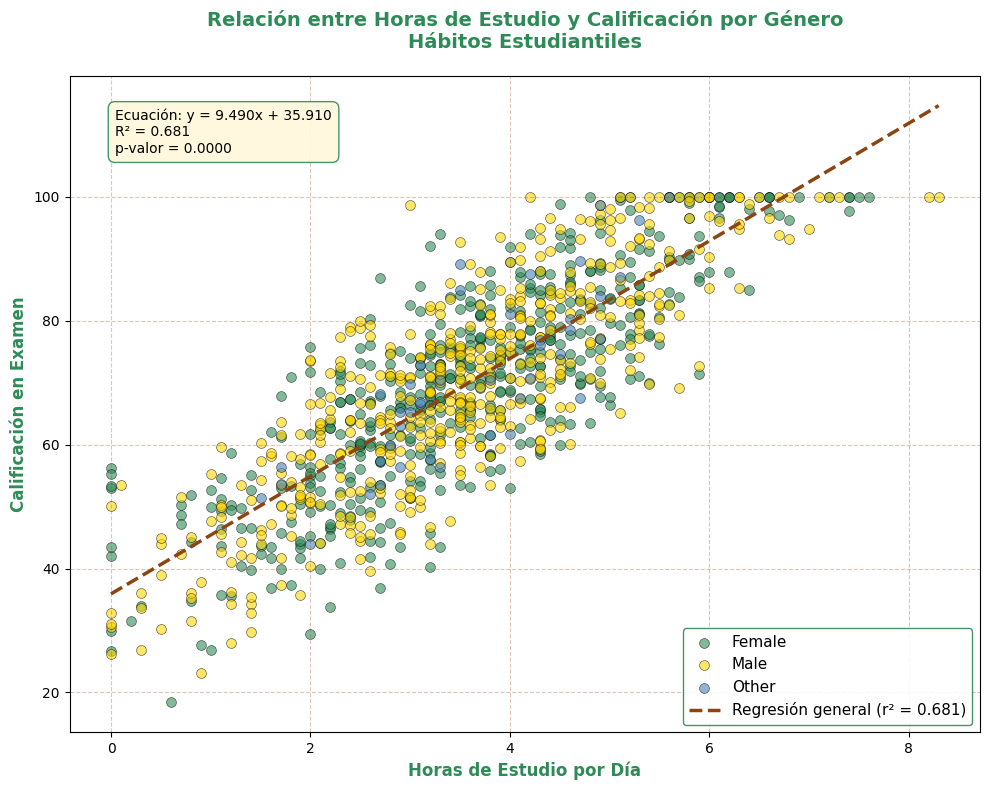

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats

colores_genero = {
    'Female': '#2E8B57',
    'Male': '#FFD700',
    'Other': '#4682B4'
}

plt.figure(figsize=(10, 8))

for genero, color in colores_genero.items():
    subset = habits[habits['gender'] == genero]
    plt.scatter(subset['study_hours_per_day'], subset['exam_score'], 
                alpha=0.6, s=50, c=color, edgecolors='black', linewidth=0.5, 
                label=f'{genero}')

x = habits['study_hours_per_day']
y = habits['exam_score']
slope, intercept, r_value, p_value, std_err = stats.linregress(x, y)
r_squared = r_value ** 2

x_line = np.linspace(x.min(), x.max(), 100)
y_line = slope * x_line + intercept
plt.plot(x_line, y_line, color='#8B4513', linewidth=2.5, linestyle='--', 
         label=f'Regresión general (r² = {r_squared:.3f})')

plt.xlabel('Horas de Estudio por Día', fontsize=12, fontweight='bold', color='#2E8B57')
plt.ylabel('Calificación en Examen', fontsize=12, fontweight='bold', color='#2E8B57')
plt.title('Relación entre Horas de Estudio y Calificación por Género\nHábitos Estudiantiles', 
          fontsize=14, fontweight='bold', color='#2E8B57', pad=20)

plt.grid(True, alpha=0.3, linestyle='--', color='#8B4513')
plt.legend(loc='lower right', fontsize=11, framealpha=0.9, edgecolor='#2E8B57')

plt.text(0.05, 0.95, f'Ecuación: y = {slope:.3f}x + {intercept:.3f}\nR² = {r_squared:.3f}\np-valor = {p_value:.4f}', 
         transform=plt.gca().transAxes, fontsize=10, 
         bbox=dict(boxstyle="round,pad=0.5", facecolor='#FFF8DC', edgecolor='#2E8B57', alpha=0.9),
         verticalalignment='top')

plt.tight_layout()
plt.show()

Ahora, graficaremos la relación entre las variables categóricas con el resultado del examen:

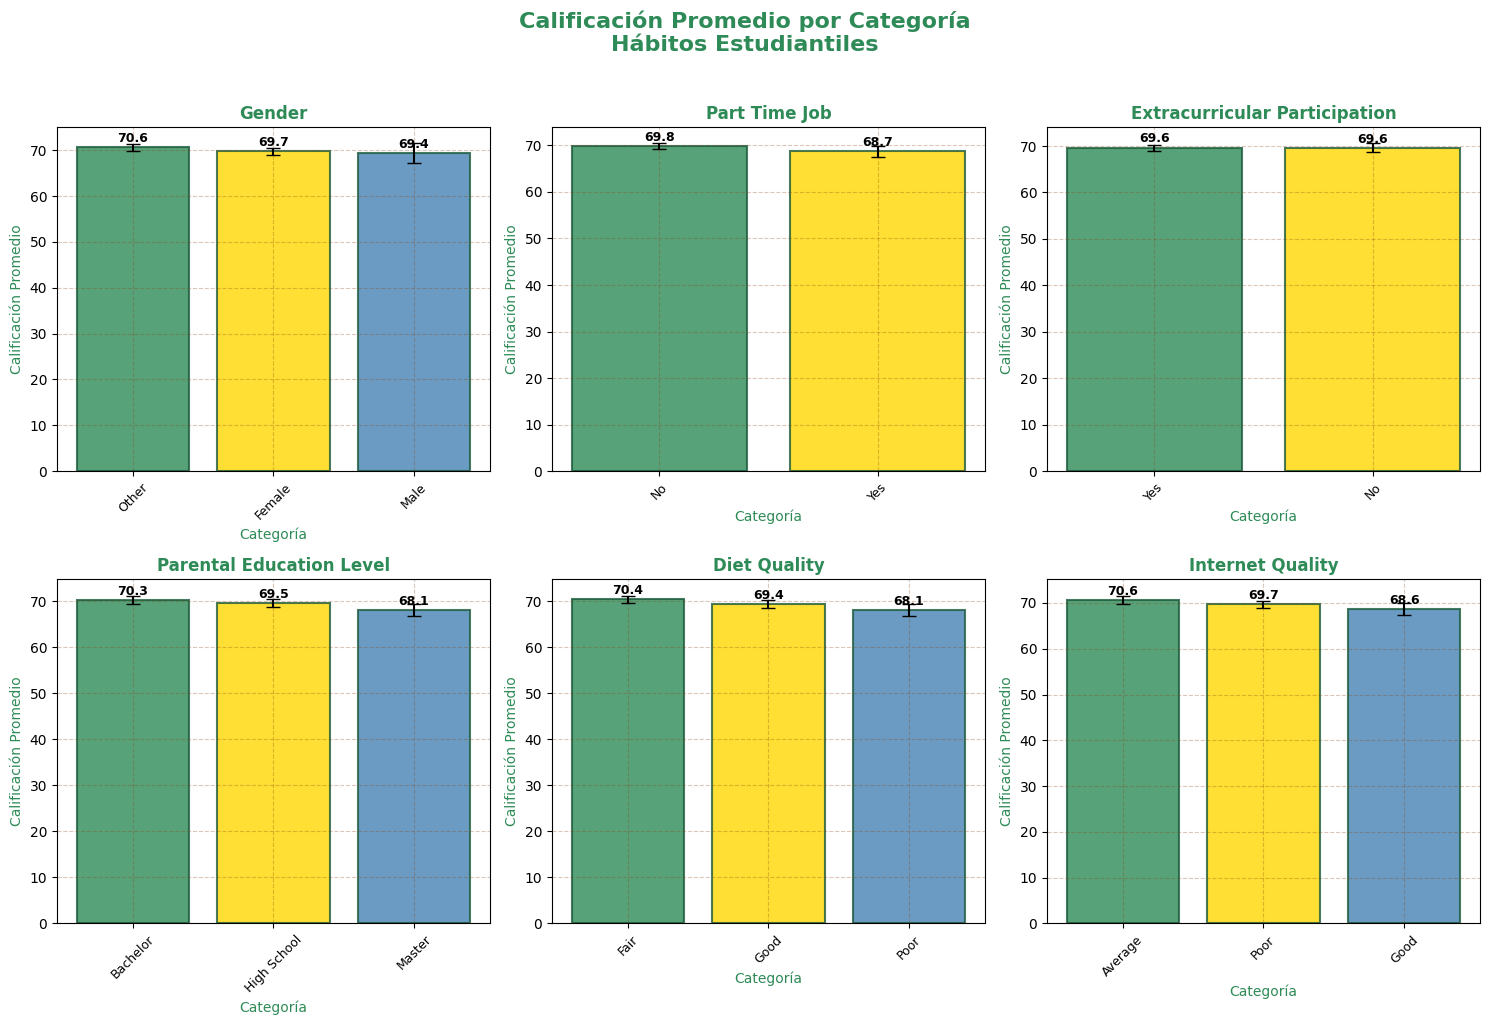

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

categorical_columns = ['gender', 'part_time_job', 'extracurricular_participation', 'parental_education_level', 'diet_quality','internet_quality']

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

colores_escolares = ['#2E8B57', '#FFD700', '#4682B4', '#FF8C00', '#8B4513']

for idx, col in enumerate(categorical_columns):
    if idx < len(axes):
        media = habits.groupby(col)['exam_score'].mean().sort_values(ascending=False)
        error = habits.groupby(col)['exam_score'].sem()
        
        bars = axes[idx].bar(media.index, media.values, 
                            color=colores_escolares[:len(media)], 
                            edgecolor='#1a5a3a', linewidth=1.5,
                            yerr=error.values, capsize=5, alpha=0.8)
        
        axes[idx].set_title(col.replace('_', ' ').title(), fontsize=12, fontweight='bold', color='#2E8B57')
        axes[idx].set_xlabel('Categoría', fontsize=10, color='#2E8B57')
        axes[idx].set_ylabel('Calificación Promedio', fontsize=10, color='#2E8B57')
        axes[idx].grid(True, alpha=0.3, linestyle='--', color='#8B4513')
        axes[idx].tick_params(axis='x', rotation=45, labelsize=9)
        
        for bar in bars:
            height = bar.get_height()
            axes[idx].text(bar.get_x() + bar.get_width()/2., height + 0.5,
                          f'{height:.1f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

for idx in range(len(categorical_columns), len(axes)):
    axes[idx].set_visible(False)

plt.suptitle('Calificación Promedio por Categoría\nHábitos Estudiantiles', 
             fontsize=16, fontweight='bold', color='#2E8B57', y=1.02)

plt.tight_layout()
plt.show()

Podemos notar, que parece no tener mucha incidencia en la variable `exam_score`. Lo cual coincide con lo mencionado arriba respecto a las correlaciones.